1. DATA PREPARATION & AUGMENTATION

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


2. MODEL ARCHITECTURE (ResNet18)

In [6]:
print("--- Loading ResNet18 ---")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

--- Loading ResNet18 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


3. HYPERPARAMETERS & OPTIMIZATION CONFIGURATION

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

4. TRAINING & VALIDATION LOOP

In [8]:
train_losses, test_losses = [], []
test_accuracies = []

epochs = 20

print("Starting Training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(trainloader.dataset)
    train_losses.append(epoch_train_loss)

    scheduler.step()

    # --- VALIDATION/TEST PHASE ---
    model.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / len(testloader.dataset)
    epoch_test_acc = 100 * correct / total

    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)

    print(f"Epoch {epoch+1}/{epochs} -> "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Test Loss: {epoch_test_loss:.4f} | "
          f"Test Accuracy: {epoch_test_acc:.2f}%")

print("Training Finished successfully!")

Starting Training...
Epoch 1/20 -> Train Loss: 0.5662 | Test Loss: 0.3248 | Test Accuracy: 89.56%
Epoch 2/20 -> Train Loss: 0.2965 | Test Loss: 0.3396 | Test Accuracy: 89.13%
Epoch 3/20 -> Train Loss: 0.2259 | Test Loss: 0.2316 | Test Accuracy: 92.15%
Epoch 4/20 -> Train Loss: 0.1806 | Test Loss: 0.2321 | Test Accuracy: 92.48%
Epoch 5/20 -> Train Loss: 0.1456 | Test Loss: 0.2160 | Test Accuracy: 93.12%
Epoch 6/20 -> Train Loss: 0.1233 | Test Loss: 0.2017 | Test Accuracy: 93.46%
Epoch 7/20 -> Train Loss: 0.0965 | Test Loss: 0.1995 | Test Accuracy: 93.87%
Epoch 8/20 -> Train Loss: 0.0790 | Test Loss: 0.2094 | Test Accuracy: 93.73%
Epoch 9/20 -> Train Loss: 0.0616 | Test Loss: 0.1957 | Test Accuracy: 94.24%
Epoch 10/20 -> Train Loss: 0.0465 | Test Loss: 0.1972 | Test Accuracy: 94.16%
Epoch 11/20 -> Train Loss: 0.0381 | Test Loss: 0.1830 | Test Accuracy: 94.99%
Epoch 12/20 -> Train Loss: 0.0232 | Test Loss: 0.1842 | Test Accuracy: 94.99%
Epoch 13/20 -> Train Loss: 0.0190 | Test Loss: 0.174

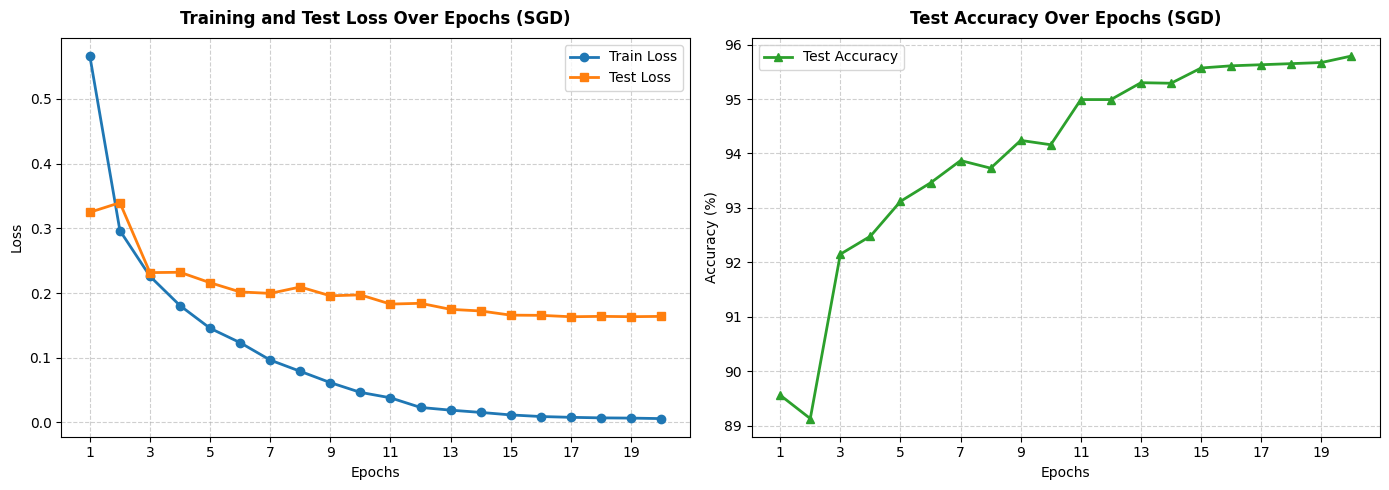

In [9]:
epochs = 20
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', color='#ff7f0e', linewidth=2, marker='s')
plt.title('Training and Test Loss Over Epochs (SGD)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, epochs + 1, 2))
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), test_accuracies, label='Test Accuracy', color='#2ca02c', linewidth=2, marker='^')
plt.title('Test Accuracy Over Epochs (SGD)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, epochs + 1, 2))
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

all_predictions = []
all_targets = []

model.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

print("=== CLASSIFICATION REPORT ===")
print(classification_report(all_targets, all_predictions, target_names=classes, digits=4))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       plane     0.9620    0.9630    0.9625      1000
         car     0.9713    0.9830    0.9771      1000
        bird     0.9616    0.9510    0.9563      1000
         cat     0.9048    0.9030    0.9039      1000
        deer     0.9455    0.9710    0.9581      1000
         dog     0.9235    0.9290    0.9262      1000
        frog     0.9828    0.9730    0.9779      1000
       horse     0.9837    0.9670    0.9753      1000
        ship     0.9778    0.9690    0.9734      1000
       truck     0.9671    0.9700    0.9685      1000

    accuracy                         0.9579     10000
   macro avg     0.9580    0.9579    0.9579     10000
weighted avg     0.9580    0.9579    0.9579     10000

